# Predicting Employee Attrition in Nigerian Financial Institutions
## Using Advanced Machine Learning Techniques

---

**Dissertation Reconstruction | University of East London - MSc Data Science | Distinction | 2025**

---

### Project Background

This notebook reconstructs an end-to-end attrition modelling workflow for HR risk prediction.
It has been updated to be resilient to dataset refreshes by reducing hardcoded assumptions.

### Dataset

- Source file is auto-detected (prefers nigerian_bank_hr_dataset.csv when present)
- Shape and schema are discovered at runtime
- Target handling is robust to common positive-label variants (Yes/1/True/Left/Resigned)

---

In [31]:
# Install required libraries
%pip install imbalanced-learn -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Import Libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_classif
from sklearn.pipeline import make_pipeline
from sklearn.base import clone
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score, f1_score,
    average_precision_score, precision_recall_curve, brier_score_loss
)
from imblearn.over_sampling import SMOTE

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
pd.set_option('display.max_columns', 50)

print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Load Dataset


In [3]:
from pathlib import Path

# Prefer the expected file name; otherwise auto-pick the largest CSV in the workspace
preferred_file = Path('nigerian_bank_hr_dataset.csv')
csv_candidates = sorted(Path('.').glob('*.csv'))

if preferred_file.exists():
    data_path = preferred_file
elif csv_candidates:
    data_path = max(csv_candidates, key=lambda p: p.stat().st_size)
else:
    raise FileNotFoundError('No CSV file found in the current workspace folder.')

df = pd.read_csv(data_path)

print('\nDataset loaded successfully.')
print(f'File: {data_path.name}')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()


Dataset loaded successfully.
File: nigerian_bank_hr_dataset.csv
Shape: 5,000 rows x 36 columns


,EmployeeID,HireDate,ExitDate,EmploymentStatus,EmploymentType,Age,Gender,MaritalStatus,StateOfOrigin,Education,EducationField,Department,JobLevel,YearsAtCompany,YearsInRole,TotalWorkingYears,YearsSinceLastPromotion,NumberOfPromotions,MonthlyIncome,SalaryBand,LastSalaryIncreasePct,BonusReceived,PerformanceRating,TrainingTimesLastYear,TargetsMetPct,JobSatisfaction,WorkLifeBalance,ManagerRelationship,EnvironmentSatisfaction,EngagementScore,DistanceFromHome,OvertimeFrequency,BusinessTravel,RemoteWorkOption,Attrition,Reason_for_Leaving
0,EMP-00001,1/2/2015,NaN,Active,Permanent,33,Male,Single,Lagos,3,Statistics,Central Operations Department,2,10.0,0.9,10.0,4.3,1,546974,Junior,9.7,Yes,3,3,88.5,2,2,4,1,57,8,Never,Occasional,No,No,NaN
1,EMP-00002,1/3/2015,7/12/2023,Resigned,Permanent,25,Male,Single,Plateau,3,Finance,Credit Administration Department,2,10.0,4.7,10.0,4.4,0,512262,Junior,6.6,Yes,4,1,96.2,1,1,1,1,24,678,Sometimes,No Travel,No,Yes,CAREER PROGRESSION
2,EMP-00003,1/3/2015,NaN,Active,Permanent,35,Male,Single,Lagos,5,Information Technology,Retail Banking Department,4,10.0,7.8,10.9,5.0,4,2023175,Senior,7.9,Yes,3,0,74.6,4,2,2,1,57,18,Sometimes,Frequent,No,No,NaN
3,EMP-00004,1/3/2015,NaN,Active,Contract,26,Female,Single,Osun,2,Economics,Internal Audit Department,1,10.0,4.5,10.0,1.1,0,185335,Contract,2.9,No,3,0,81.4,4,3,2,3,78,367,Never,Frequent,No,No,NaN
4,EMP-00005,1/5/2015,NaN,Active,Permanent,24,Female,Single,Anambra,3,Accounting,Risk Management Department,2,10.0,2.3,10.0,2.7,0,638880,Junior,10.5,No,2,4,57.9,2,2,2,2,51,699,Often,Frequent,No,No,NaN


## 3. Initial Data Exploration


In [4]:
# Dataset info
print('=== DATASET INFORMATION ===')
print(df.info())

print('\n=== MISSING VALUES ===')
nulls = df.isnull().sum()
print(nulls[nulls > 0])

target_col = 'Attrition'
if target_col not in df.columns:
    raise KeyError(f"Expected target column '{target_col}' not found in dataset.")

print('\n=== TARGET VARIABLE DISTRIBUTION ===')
target_str = df[target_col].astype(str).str.strip()
print(target_str.value_counts(dropna=False))

positive_tokens = {'yes', '1', 'true', 'attrition', 'left', 'resigned'}
attrition_rate = target_str.str.lower().isin(positive_tokens).mean()
print(f"\nApprox. Attrition Rate (auto-inferred positive class): {attrition_rate:.1%}")

=== DATASET INFORMATION ===
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EmployeeID               5000 non-null   str    
 1   HireDate                 5000 non-null   str    
 2   ExitDate                 1283 non-null   str    
 3   EmploymentStatus         5000 non-null   str    
 4   EmploymentType           5000 non-null   str    
 5   Age                      5000 non-null   int64  
 6   Gender                   5000 non-null   str    
 7   MaritalStatus            5000 non-null   str    
 8   StateOfOrigin            5000 non-null   str    
 9   Education                5000 non-null   int64  
 10  EducationField           5000 non-null   str    
 11  Department               5000 non-null   str    
 12  JobLevel                 5000 non-null   int64  
 13  YearsAtCompany           5000 non-null   float64
 14  YearsIn

In [5]:
# Basic statistics for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_cols].describe().round(2)

,Age,Education,JobLevel,YearsAtCompany,YearsInRole,TotalWorkingYears,YearsSinceLastPromotion,NumberOfPromotions,MonthlyIncome,LastSalaryIncreasePct,PerformanceRating,TrainingTimesLastYear,TargetsMetPct,JobSatisfaction,WorkLifeBalance,ManagerRelationship,EnvironmentSatisfaction,EngagementScore,DistanceFromHome
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,35.18,3.30,2.72,5.21,2.53,9.06,2.54,1.53,1407225.40,7.87,2.59,2.10,69.41,2.47,2.37,2.39,2.42,57.84,330.68
std,7.68,0.84,1.09,2.72,1.86,4.94,1.73,1.45,1440550.44,4.12,1.03,1.25,21.33,1.06,1.04,1.04,1.06,19.55,250.48
min,22.00,1.00,1.00,0.50,0.30,0.50,0.00,0.00,150028.00,0.00,1.00,0.00,20.10,1.00,1.00,1.00,1.00,1.00,1.00
25%,29.00,3.00,2.00,2.80,1.00,5.80,1.10,0.00,615439.25,4.50,2.00,1.00,54.20,2.00,2.00,2.00,2.00,42.00,56.00
50%,34.00,3.00,3.00,5.20,2.00,8.40,2.20,1.00,879862.00,7.70,3.00,2.00,73.60,2.00,2.00,2.00,2.00,58.00,339.00
75%,40.00,4.00,3.00,7.50,3.60,11.00,3.80,2.00,1470075.75,11.10,3.00,3.00,88.10,3.00,3.00,3.00,3.00,73.00,543.00
max,57.00,5.00,5.00,10.00,8.60,33.80,8.20,6.00,7978023.00,20.00,4.00,5.00,100.00,4.00,4.00,4.00,4.00,100.00,799.00


## 4. Exploratory Data Analysis

Before building models, we explore the data to understand the distribution of attrition 
across key variables and identify patterns that may inform feature engineering and model selection.


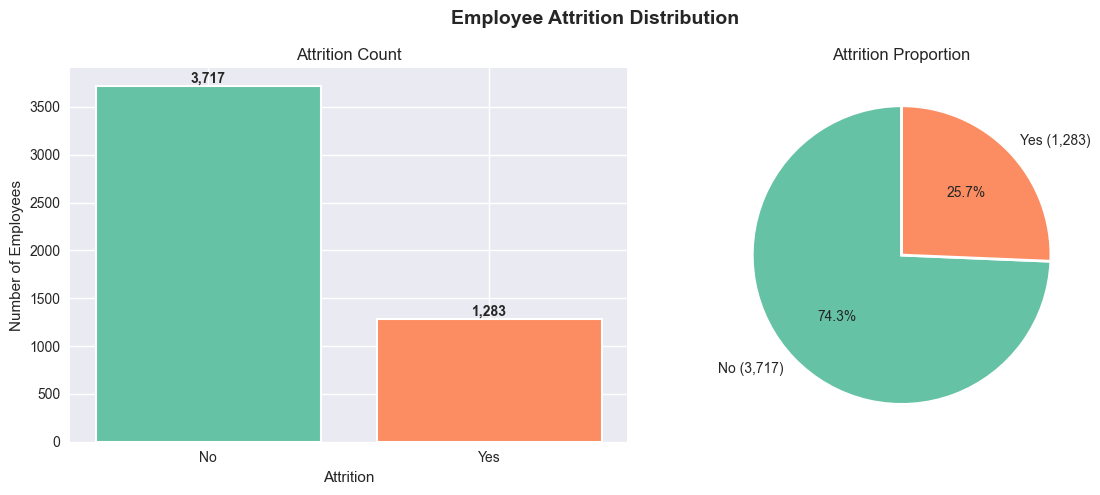

Approx. attrition rate: 25.7%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Employee Attrition Distribution', fontsize=14, fontweight='bold')

target_str = df['Attrition'].astype(str).str.strip()
attrition_counts = target_str.value_counts()
labels = attrition_counts.index.astype(str).tolist()
colors = sns.color_palette('Set2', n_colors=len(attrition_counts))

# Count plot
bars = axes[0].bar(labels, attrition_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Attrition Count')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Number of Employees')
offset = max(5, int(attrition_counts.max() * 0.01))
for bar, v in zip(bars, attrition_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + offset, f'{v:,}', ha='center', fontweight='bold')

# Pie chart (dynamic labels)
pie_labels = [f'{lbl} ({cnt:,})' for lbl, cnt in zip(labels, attrition_counts.values)]
axes[1].pie(
    attrition_counts.values,
    labels=pie_labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
 )
axes[1].set_title('Attrition Proportion')

plt.tight_layout()
plt.savefig('attrition_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

positive_tokens = {'yes', '1', 'true', 'attrition', 'left', 'resigned'}
print(f"Approx. attrition rate: {target_str.str.lower().isin(positive_tokens).mean():.1%}")

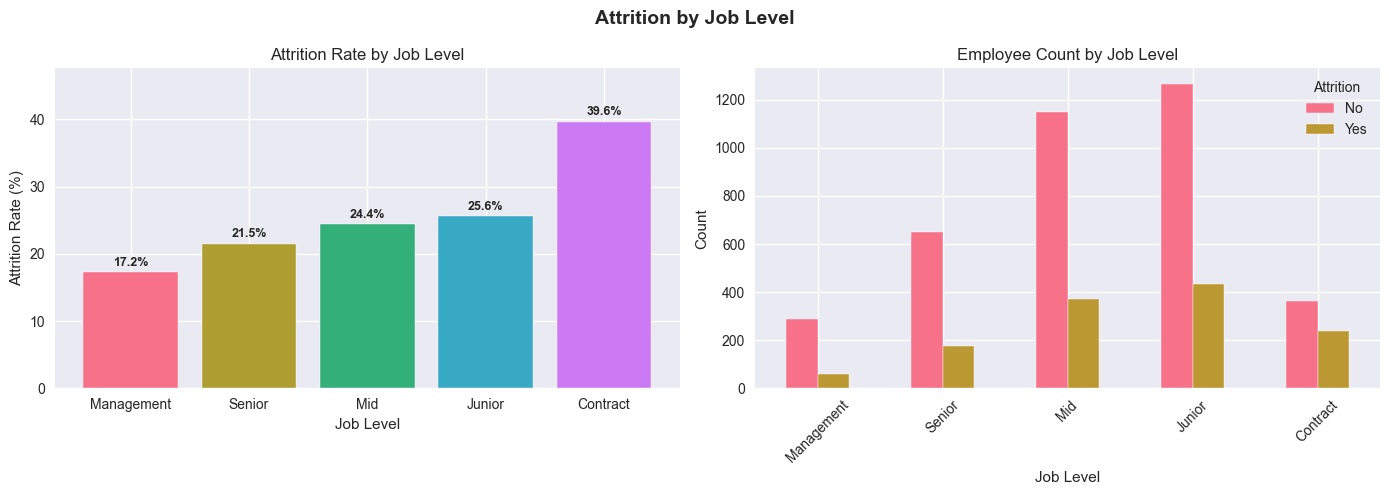

In [7]:
if 'JobLevel' in df.columns and 'Attrition' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Attrition by Job Level', fontsize=14, fontweight='bold')

    # Build labels dynamically; map common numeric levels when possible
    level_labels = {1: 'Contract', 2: 'Junior', 3: 'Mid', 4: 'Senior', 5: 'Management'}
    joblevel_series = df['JobLevel']
    if pd.api.types.is_numeric_dtype(joblevel_series):
        df['JobLevelLabel'] = joblevel_series.map(level_labels).fillna(joblevel_series.astype(str))
    else:
        df['JobLevelLabel'] = joblevel_series.astype(str)

    # Attrition rate by job level
    target_str = df['Attrition'].astype(str).str.strip().str.lower()
    yes_mask = target_str.isin({'yes', '1', 'true', 'attrition', 'left', 'resigned'})
    temp_df = df[['JobLevelLabel']].copy()
    temp_df['AttritionBinary'] = yes_mask.astype(int)
    level_attrition = temp_df.groupby('JobLevelLabel')['AttritionBinary'].mean().mul(100).sort_values()

    bars = axes[0].bar(level_attrition.index, level_attrition.values,
                       color=sns.color_palette('husl', len(level_attrition)), edgecolor='white')
    axes[0].set_title('Attrition Rate by Job Level')
    axes[0].set_xlabel('Job Level')
    axes[0].set_ylabel('Attrition Rate (%)')
    ymax = max(10, level_attrition.max() * 1.2)
    axes[0].set_ylim(0, ymax)
    for bar, val in zip(bars, level_attrition.values):
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + ymax * 0.02,
                     f'{val:.1f}%', ha='center', fontweight='bold', fontsize=9)

    # Count by job level and attrition
    level_counts = df.groupby(['JobLevelLabel', 'Attrition']).size().unstack(fill_value=0)
    level_counts = level_counts.loc[level_attrition.index]
    level_counts.plot(kind='bar', ax=axes[1], edgecolor='white', rot=45)
    axes[1].set_title('Employee Count by Job Level')
    axes[1].set_xlabel('Job Level')
    axes[1].set_ylabel('Count')
    axes[1].legend(title='Attrition')

    plt.tight_layout()
    plt.savefig('attrition_by_joblevel.png', dpi=150, bbox_inches='tight')
    plt.show()
    df.drop(columns=['JobLevelLabel'], inplace=True)
else:
    print("Skipped: 'JobLevel' or 'Attrition' column not found.")

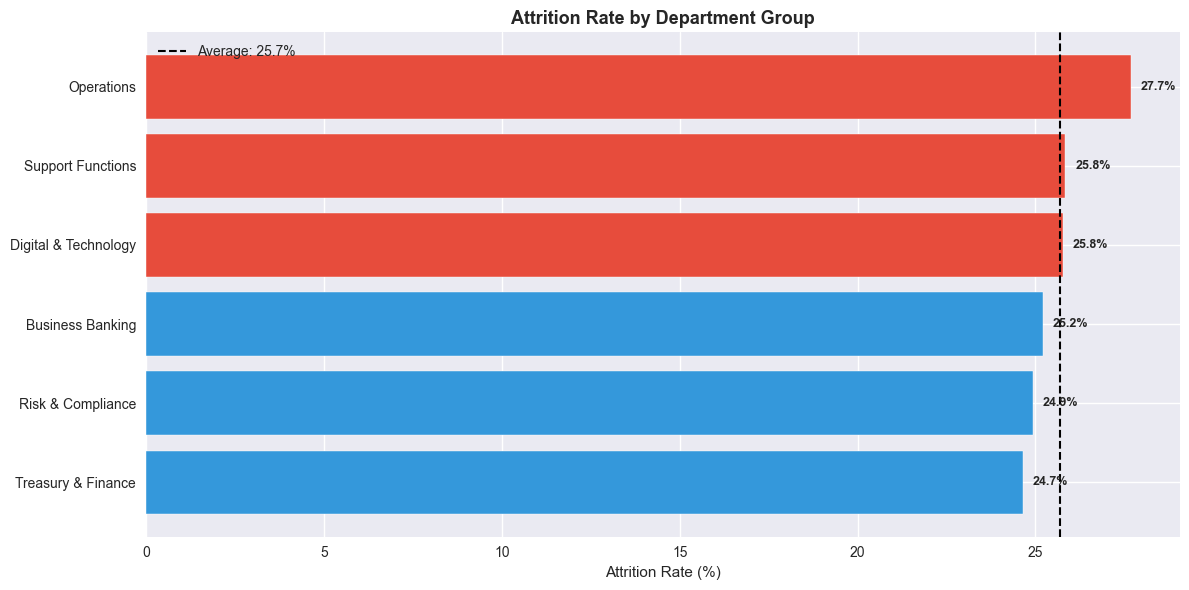

In [8]:
dept_group_mapping = {
    'Retail Banking Department': 'Business Banking',
    'Commercial Banking Department': 'Business Banking',
    'Corporate Banking Department': 'Business Banking',
    'SME Banking Department': 'Business Banking',
    'Private Banking & Wealth Management': 'Business Banking',
    'Public Sector Department': 'Business Banking',
    'Institutional Banking Department': 'Business Banking',
    'Agricultural Finance Department': 'Business Banking',
    'Treasury & Markets Department': 'Treasury & Finance',
    'Foreign Exchange (FX) Operations': 'Treasury & Finance',
    'Trade Services Department': 'Treasury & Finance',
    'International Remittances Department': 'Treasury & Finance',
    'Asset Management Department': 'Treasury & Finance',
    'Branch Operations Department': 'Operations',
    'Cash Management & Vault Operations': 'Operations',
    'Clearing & Settlement Department': 'Operations',
    'Central Operations Department': 'Operations',
    'Digital Banking Department': 'Digital & Technology',
    'Alternative Channels Department': 'Digital & Technology',
    'Card Services Department': 'Digital & Technology',
    'Information Technology (IT) Department': 'Digital & Technology',
    'Core Banking Applications Support': 'Digital & Technology',
    'Information & Cyber Security Department': 'Digital & Technology',
    'Data Analytics & Business Intelligence': 'Digital & Technology',
    'Risk Management Department': 'Risk & Compliance',
    'Credit Administration Department': 'Risk & Compliance',
    'Legal Department': 'Risk & Compliance',
    'Regulatory Compliance Department': 'Risk & Compliance',
    'Internal Audit Department': 'Risk & Compliance',
    'Internal Control & Anti-Fraud Unit': 'Risk & Compliance',
    'Customer Service / Customer Experience Department': 'Support Functions',
    'Human Resources & Talent Management': 'Support Functions',
    'Finance & Corporate Strategy Department': 'Support Functions',
    'Corporate Communications & Marketing': 'Support Functions',
    'Procurement & Supply Chain Department': 'Support Functions',
    'Facilities & Administrative Services': 'Support Functions',
    'Corporate Social Responsibility (CSR) Unit': 'Support Functions'
}

df['DepartmentGroup'] = df['Department'].map(dept_group_mapping).fillna('Other/Unmapped')

fig, ax = plt.subplots(figsize=(12, 6))
dept_attrition = df.groupby('DepartmentGroup')['Attrition'].apply(
    lambda x: x.astype(str).str.strip().str.lower().isin({'yes', '1', 'true', 'attrition', 'left', 'resigned'}).mean() * 100
).sort_values(ascending=True)

colors = ['#e74c3c' if v > dept_attrition.mean() else '#3498db' for v in dept_attrition.values]
bars = ax.barh(dept_attrition.index, dept_attrition.values, color=colors, edgecolor='white')
ax.axvline(x=dept_attrition.mean(), color='black', linestyle='--',
           linewidth=1.5, label=f'Average: {dept_attrition.mean():.1f}%')
ax.set_title('Attrition Rate by Department Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Attrition Rate (%)')
for bar, val in zip(bars, dept_attrition.values):
    ax.text(val + max(0.1, dept_attrition.max() * 0.01), bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontweight='bold', fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig('attrition_by_department.png', dpi=150, bbox_inches='tight')
plt.show()

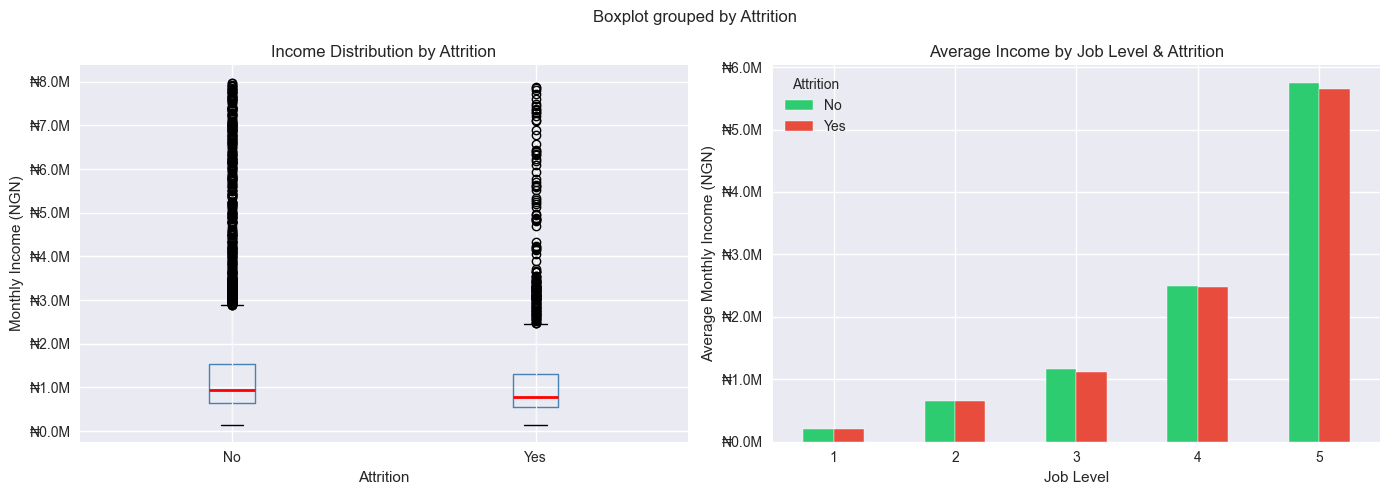

Mean Monthly Income by Attrition:
Attrition
No     ₦1,481,589
Yes    ₦1,191,785


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Monthly Income Analysis by Attrition', fontsize=14, fontweight='bold')

# Box plot
df.boxplot(column='MonthlyIncome', by='Attrition', ax=axes[0],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Income Distribution by Attrition')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Monthly Income (NGN)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₦{x/1e6:.1f}M'))
plt.sca(axes[0])
plt.title('Income Distribution by Attrition')

# Mean income by job level and attrition
income_level = df.groupby(['JobLevel', 'Attrition'])['MonthlyIncome'].mean().unstack()
income_level.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'],
                  edgecolor='white', rot=0)
axes[1].set_title('Average Income by Job Level & Attrition')
axes[1].set_xlabel('Job Level')
axes[1].set_ylabel('Average Monthly Income (NGN)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₦{x/1e6:.1f}M'))
axes[1].legend(title='Attrition')

plt.tight_layout()
plt.savefig('income_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('Mean Monthly Income by Attrition:')
print(df.groupby('Attrition')['MonthlyIncome'].mean().apply(lambda x: f'₦{x:,.0f}').to_string())

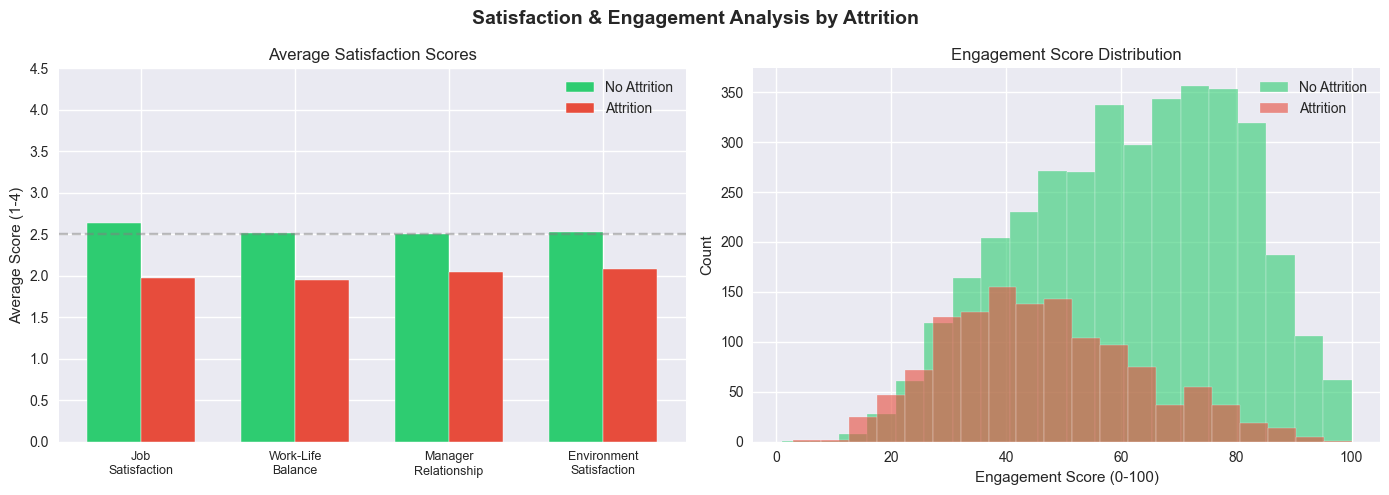

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Satisfaction & Engagement Analysis by Attrition', fontsize=14, fontweight='bold')

sat_cols = ['JobSatisfaction', 'WorkLifeBalance', 'ManagerRelationship', 'EnvironmentSatisfaction']
sat_means = df.groupby('Attrition')[sat_cols].mean()

x = np.arange(len(sat_cols))
width = 0.35
axes[0].bar(x - width/2, sat_means.loc['No'], width, label='No Attrition',
            color='#2ecc71', edgecolor='white')
axes[0].bar(x + width/2, sat_means.loc['Yes'], width, label='Attrition',
            color='#e74c3c', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Job\nSatisfaction', 'Work-Life\nBalance',
                          'Manager\nRelationship', 'Environment\nSatisfaction'], fontsize=9)
axes[0].set_ylabel('Average Score (1-4)')
axes[0].set_title('Average Satisfaction Scores')
axes[0].set_ylim(0, 4.5)
axes[0].legend()
axes[0].axhline(y=2.5, color='grey', linestyle='--', alpha=0.5, label='Midpoint')

# Engagement score distribution
for attrition_val, color, label in [('No', '#2ecc71', 'No Attrition'), ('Yes', '#e74c3c', 'Attrition')]:
    data = df[df['Attrition'] == attrition_val]['EngagementScore']
    axes[1].hist(data, bins=20, alpha=0.6, color=color, label=label, edgecolor='white')
axes[1].set_title('Engagement Score Distribution')
axes[1].set_xlabel('Engagement Score (0-100)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('satisfaction_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

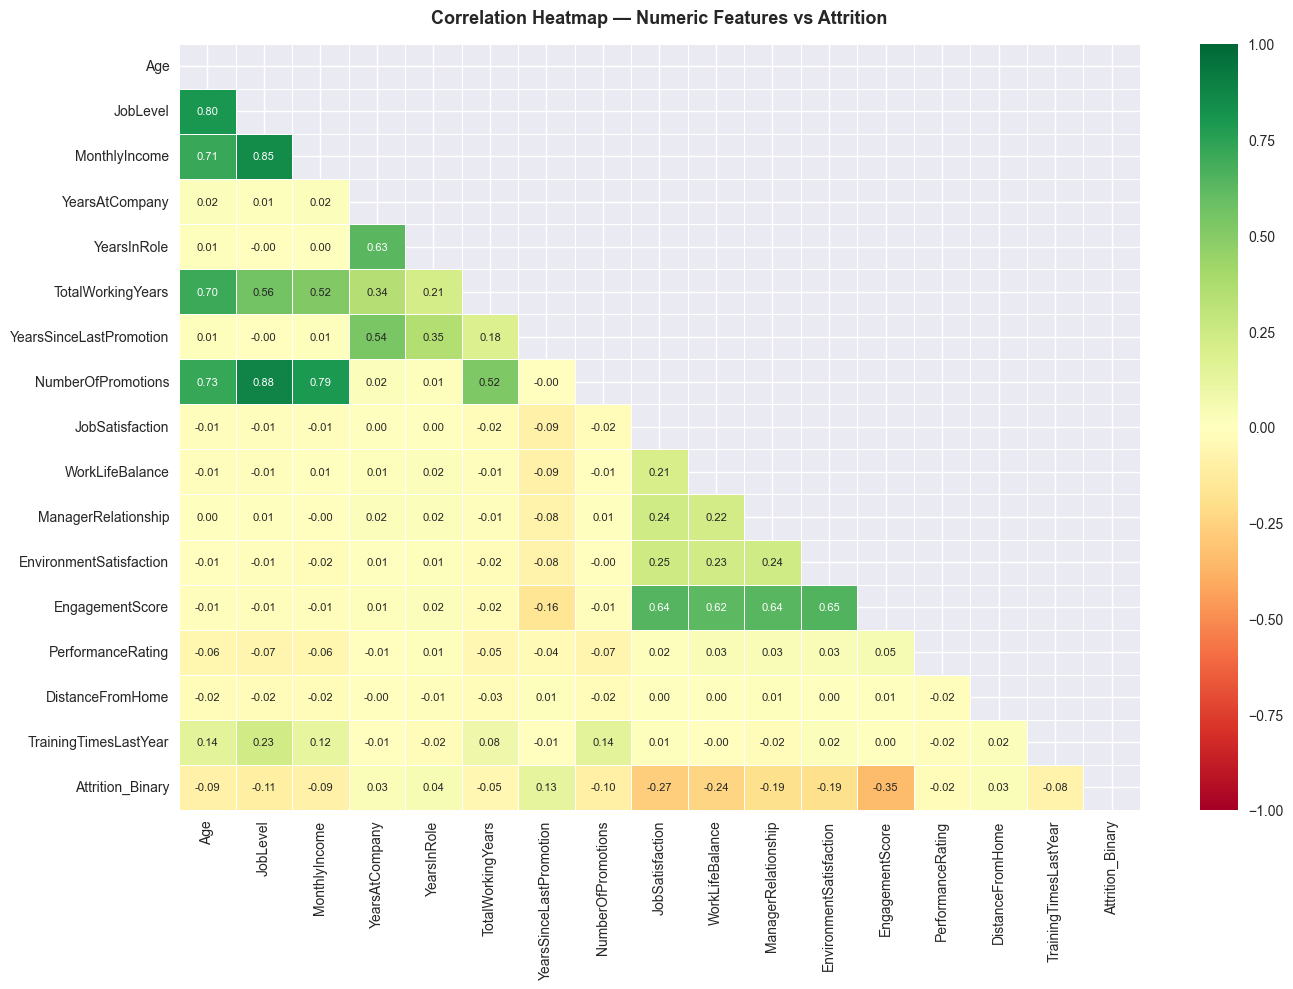

Top correlations with Attrition:
EngagementScore           -0.346
JobSatisfaction           -0.269
WorkLifeBalance           -0.236
ManagerRelationship       -0.194
EnvironmentSatisfaction   -0.189
YearsSinceLastPromotion    0.127
JobLevel                  -0.109
NumberOfPromotions        -0.095
Age                       -0.088
MonthlyIncome             -0.088


In [11]:
df_temp = df.copy()
df_temp['Attrition_Binary'] = (df_temp['Attrition'] == 'Yes').astype(int)

corr_cols = [
    'Age', 'JobLevel', 'MonthlyIncome', 'YearsAtCompany', 'YearsInRole',
    'TotalWorkingYears', 'YearsSinceLastPromotion', 'NumberOfPromotions',
    'JobSatisfaction', 'WorkLifeBalance', 'ManagerRelationship',
    'EnvironmentSatisfaction', 'EngagementScore', 'PerformanceRating',
    'DistanceFromHome', 'TrainingTimesLastYear', 'Attrition_Binary'
]

corr_matrix = df_temp[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={'size': 8}
)
ax.set_title('Correlation Heatmap — Numeric Features vs Attrition',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Show top correlations with attrition
print('Top correlations with Attrition:')
print(corr_matrix['Attrition_Binary'].drop('Attrition_Binary')
      .sort_values(key=abs, ascending=False).head(10).round(3).to_string())

## 5. Data Preprocessing

Before training models we perform the following steps:
1. **Remove leakage columns** - columns that would not be available at prediction time
2. **Feature engineering** - group high-cardinality categoricals into meaningful groups
3. **Encode categorical variables** - convert text categories to numeric
4. **Scale numeric features** - standardise features for distance-based models


In [12]:
df_model = df.copy()

# Drop leakage and non-predictive columns only if present
drop_cols = ['EmployeeID', 'HireDate', 'ExitDate',
             'EmploymentStatus', 'Reason_for_Leaving', 'SalaryBand']
existing_drop_cols = [c for c in drop_cols if c in df_model.columns]
df_model.drop(columns=existing_drop_cols, inplace=True, errors='ignore')
print(f'Dropped leakage/identifier columns: {existing_drop_cols}')

# Map StateOfOrigin to Nigerian Geopolitical Zones
zone_mapping = {
    'Lagos': 'South West', 'Ogun': 'South West', 'Oyo': 'South West',
    'Osun': 'South West', 'Ondo': 'South West', 'Ekiti': 'South West',
    'Anambra': 'South East', 'Enugu': 'South East', 'Imo': 'South East',
    'Abia': 'South East', 'Ebonyi': 'South East',
    'Rivers': 'South South', 'Delta': 'South South', 'Edo': 'South South',
    'Akwa Ibom': 'South South', 'Cross River': 'South South', 'Bayelsa': 'South South',
    'Kano': 'North West', 'Kaduna': 'North West', 'Katsina': 'North West',
    'Sokoto': 'North West', 'Zamfara': 'North West', 'Kebbi': 'North West', 'Jigawa': 'North West',
    'Borno': 'North East', 'Yobe': 'North East', 'Adamawa': 'North East',
    'Gombe': 'North East', 'Bauchi': 'North East', 'Taraba': 'North East',
    'Abuja (FCT)': 'North Central', 'Niger': 'North Central', 'Benue': 'North Central',
    'Kogi': 'North Central', 'Kwara': 'North Central',
    'Plateau': 'North Central', 'Nasarawa': 'North Central'
}

if 'StateOfOrigin' in df_model.columns:
    df_model['GeopoliticalZone'] = df_model['StateOfOrigin'].map(zone_mapping).fillna('Other/Unknown')
    df_model.drop(columns=['StateOfOrigin'], inplace=True)

# Map Department to Functional Group
if 'Department' in df_model.columns:
    df_model['DepartmentGroup'] = df_model['Department'].map(dept_group_mapping).fillna('Other/Unmapped')
    df_model.drop(columns=['Department'], inplace=True)

print('\nFeature engineering complete.')
print(f'Shape after preprocessing: {df_model.shape}')
print(f'\nColumns: {list(df_model.columns)}')

Dropped leakage/identifier columns: ['EmployeeID', 'HireDate', 'ExitDate', 'EmploymentStatus', 'Reason_for_Leaving', 'SalaryBand']

Feature engineering complete.
Shape after preprocessing: (5000, 30)

Columns: ['EmploymentType', 'Age', 'Gender', 'MaritalStatus', 'Education', 'EducationField', 'JobLevel', 'YearsAtCompany', 'YearsInRole', 'TotalWorkingYears', 'YearsSinceLastPromotion', 'NumberOfPromotions', 'MonthlyIncome', 'LastSalaryIncreasePct', 'BonusReceived', 'PerformanceRating', 'TrainingTimesLastYear', 'TargetsMetPct', 'JobSatisfaction', 'WorkLifeBalance', 'ManagerRelationship', 'EnvironmentSatisfaction', 'EngagementScore', 'DistanceFromHome', 'OvertimeFrequency', 'BusinessTravel', 'RemoteWorkOption', 'Attrition', 'DepartmentGroup', 'GeopoliticalZone']


In [13]:
def normalize_str(s):
    return s.astype(str).str.strip().str.lower()

def encode_binary(series, positive_values):
    return normalize_str(series).isin({v.lower() for v in positive_values}).astype(int)

# Deterministic binary encodings (more robust to case/variant labels)
if 'Gender' in df_model.columns:
    df_model['Gender'] = encode_binary(df_model['Gender'], {'Male'})
if 'EmploymentType' in df_model.columns:
    df_model['EmploymentType'] = encode_binary(df_model['EmploymentType'], {'Permanent'})
if 'BonusReceived' in df_model.columns:
    df_model['BonusReceived'] = encode_binary(df_model['BonusReceived'], {'Yes', 'True', '1'})
if 'RemoteWorkOption' in df_model.columns:
    df_model['RemoteWorkOption'] = encode_binary(df_model['RemoteWorkOption'], {'Yes', 'True', '1'})

# Deterministic ordinal encodings (fallback unknowns to median code)
overtime_map = {'never': 0, 'rarely': 1, 'sometimes': 2, 'often': 3, 'always': 4}
travel_map = {'no travel': 0, 'occasional': 1, 'frequent': 2}

if 'OvertimeFrequency' in df_model.columns:
    overtime_encoded = normalize_str(df_model['OvertimeFrequency']).map(overtime_map)
    df_model['OvertimeFrequency'] = overtime_encoded.fillna(int(np.median(list(overtime_map.values())))).astype(int)

if 'BusinessTravel' in df_model.columns:
    travel_encoded = normalize_str(df_model['BusinessTravel']).map(travel_map)
    df_model['BusinessTravel'] = travel_encoded.fillna(int(np.median(list(travel_map.values())))).astype(int)

# Encode target variable robustly
if 'Attrition' not in df_model.columns:
    raise KeyError("Expected target column 'Attrition' not found after preprocessing.")
df_model['Attrition'] = encode_binary(df_model['Attrition'], {'Yes', '1', 'True', 'Attrition', 'Left', 'Resigned'})

print('Deterministic encoding complete.')
print('\nAttrition distribution after encoding:')
print(df_model['Attrition'].value_counts())
print(f'\nAny nulls remaining: {df_model.isnull().sum().sum()}')
df_model.head()

Deterministic encoding complete.

Attrition distribution after encoding:
Attrition
0    3717
1    1283
Name: count, dtype: int64

Any nulls remaining: 0


,EmploymentType,Age,Gender,MaritalStatus,Education,EducationField,JobLevel,YearsAtCompany,YearsInRole,TotalWorkingYears,YearsSinceLastPromotion,NumberOfPromotions,MonthlyIncome,LastSalaryIncreasePct,BonusReceived,PerformanceRating,TrainingTimesLastYear,TargetsMetPct,JobSatisfaction,WorkLifeBalance,ManagerRelationship,EnvironmentSatisfaction,EngagementScore,DistanceFromHome,OvertimeFrequency,BusinessTravel,RemoteWorkOption,Attrition,DepartmentGroup,GeopoliticalZone
0,1,33,1,Single,3,Statistics,2,10.0,0.9,10.0,4.3,1,546974,9.7,1,3,3,88.5,2,2,4,1,57,8,0,1,0,0,Operations,South West
1,1,25,1,Single,3,Finance,2,10.0,4.7,10.0,4.4,0,512262,6.6,1,4,1,96.2,1,1,1,1,24,678,2,0,0,1,Risk & Compliance,North Central
2,1,35,1,Single,5,Information Technology,4,10.0,7.8,10.9,5.0,4,2023175,7.9,1,3,0,74.6,4,2,2,1,57,18,2,2,0,0,Business Banking,South West
3,0,26,0,Single,2,Economics,1,10.0,4.5,10.0,1.1,0,185335,2.9,0,3,0,81.4,4,3,2,3,78,367,0,2,0,0,Risk & Compliance,South West
4,1,24,0,Single,3,Accounting,2,10.0,2.3,10.0,2.7,0,638880,10.5,0,2,4,57.9,2,2,2,2,51,699,3,2,0,0,Risk & Compliance,South East


## 6. Train-Test Split


In [14]:
X = df_model.drop(columns=['Attrition'])
y = df_model['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Fit categorical expansion on training data only to avoid leakage
expected_categorical = ['MaritalStatus', 'EducationField', 'GeopoliticalZone', 'DepartmentGroup']
categorical_cols = [c for c in expected_categorical if c in X_train.columns]

X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=False)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=False)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# Keep feature names for downstream feature-importance plotting
feature_names = X_train_encoded.columns.tolist()

# Scale features using train-fit parameters only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print(f'Training set : {X_train.shape[0]:,} samples')
print(f'Test set     : {X_test.shape[0]:,} samples')
print(f'Features     : {X_train_encoded.shape[1]}')
print(f'\nTraining attrition rate: {y_train.mean():.1%}')
print(f'Test attrition rate    : {y_test.mean():.1%}')
print(f'Categorical columns encoded: {categorical_cols}')

Training set : 4,000 samples
Test set     : 1,000 samples
Features     : 52

Training attrition rate: 25.7%
Test attrition rate    : 25.7%
Categorical columns encoded: ['MaritalStatus', 'EducationField', 'GeopoliticalZone', 'DepartmentGroup']


## 7. Handling Class Imbalance - SMOTE

Class imbalance is assessed from the current training split at runtime.
SMOTE is applied to the training data only to improve minority-class detection while keeping
the test set untouched for unbiased evaluation.

In [15]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print('Before SMOTE:')
print(f'  No Attrition : {(y_train==0).sum():,}')
print(f'  Attrition    : {(y_train==1).sum():,}')
print(f'\nAfter SMOTE:')
print(f'  No Attrition : {(y_train_resampled==0).sum():,}')
print(f'  Attrition    : {(y_train_resampled==1).sum():,}')
print(f'\nTraining set size after SMOTE: {len(X_train_resampled):,}')

Before SMOTE:
  No Attrition : 2,974
  Attrition    : 1,026

After SMOTE:
  No Attrition : 2,974
  Attrition    : 2,974

Training set size after SMOTE: 5,948


## 8. Model Building

We train and evaluate three classification models:
1. **Logistic Regression** - interpretable baseline
2. **Random Forest** - primary ensemble model
3. **Gradient Boosting** - sequential ensemble comparison

Each model is evaluated on the held-out test set using Accuracy, F1-Score, and ROC-AUC.


In [16]:
print('Training Logistic Regression...')
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_resampled, y_train_resampled)

lr_pred  = lr_model.predict(X_test_scaled)
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print('\n=== LOGISTIC REGRESSION ===')
print(classification_report(y_test, lr_pred, target_names=['No Attrition', 'Attrition']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, lr_proba):.4f}')

Training Logistic Regression...

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

No Attrition       0.85      0.69      0.76       743
   Attrition       0.42      0.64      0.50       257

    accuracy                           0.68      1000
   macro avg       0.63      0.66      0.63      1000
weighted avg       0.74      0.68      0.70      1000

ROC-AUC Score: 0.7372


In [17]:
print('Training Random Forest...')
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_resampled, y_train_resampled)

rf_pred  = rf_model.predict(X_test_scaled)
rf_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

print('\n=== RANDOM FOREST ===')
print(classification_report(y_test, rf_pred, target_names=['No Attrition', 'Attrition']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, rf_proba):.4f}')

Training Random Forest...

=== RANDOM FOREST ===
              precision    recall  f1-score   support

No Attrition       0.79      0.89      0.84       743
   Attrition       0.52      0.33      0.40       257

    accuracy                           0.75      1000
   macro avg       0.65      0.61      0.62      1000
weighted avg       0.72      0.75      0.73      1000

ROC-AUC Score: 0.7397


In [18]:
print('Training Gradient Boosting...')
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train_resampled, y_train_resampled)

gb_pred  = gb_model.predict(X_test_scaled)
gb_proba = gb_model.predict_proba(X_test_scaled)[:, 1]

print('\n=== GRADIENT BOOSTING ===')
print(classification_report(y_test, gb_pred, target_names=['No Attrition', 'Attrition']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, gb_proba):.4f}')

Training Gradient Boosting...

=== GRADIENT BOOSTING ===
              precision    recall  f1-score   support

No Attrition       0.80      0.86      0.83       743
   Attrition       0.49      0.38      0.43       257

    accuracy                           0.74      1000
   macro avg       0.64      0.62      0.63      1000
weighted avg       0.72      0.74      0.73      1000

ROC-AUC Score: 0.7420


## 9. Model Evaluation


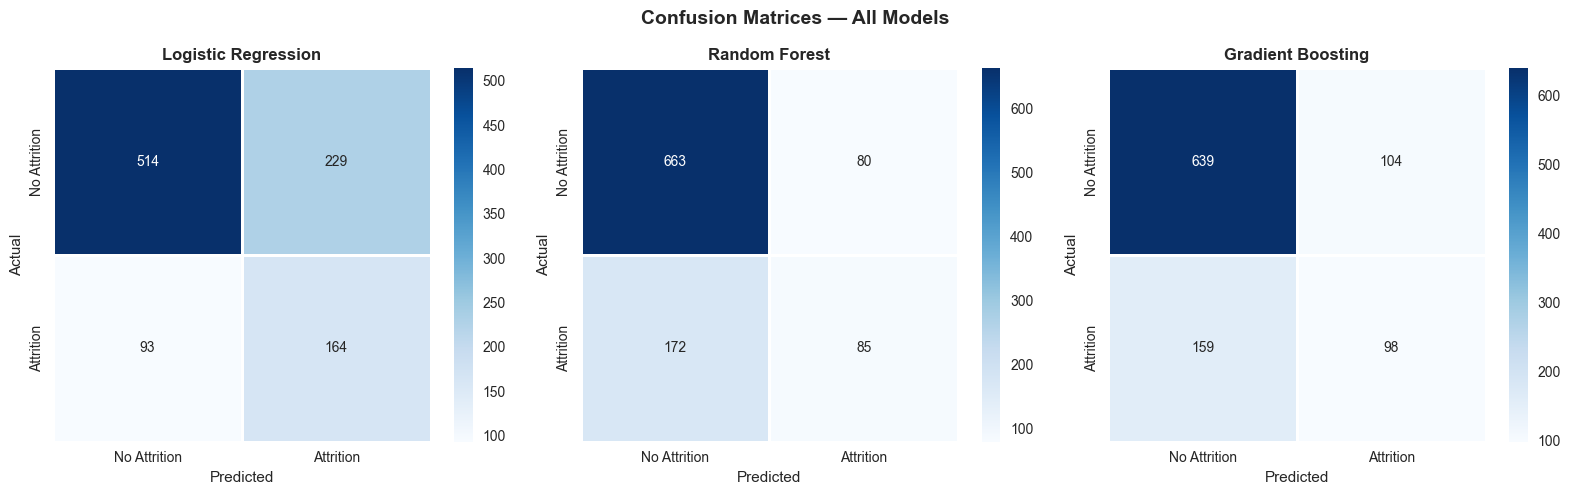

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')

models_info = [
    ('Logistic Regression', lr_pred),
    ('Random Forest',       rf_pred),
    ('Gradient Boosting',   gb_pred)
]

for ax, (name, pred) in zip(axes, models_info):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Attrition', 'Attrition'],
                yticklabels=['No Attrition', 'Attrition'],
                linewidths=1, linecolor='white')
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

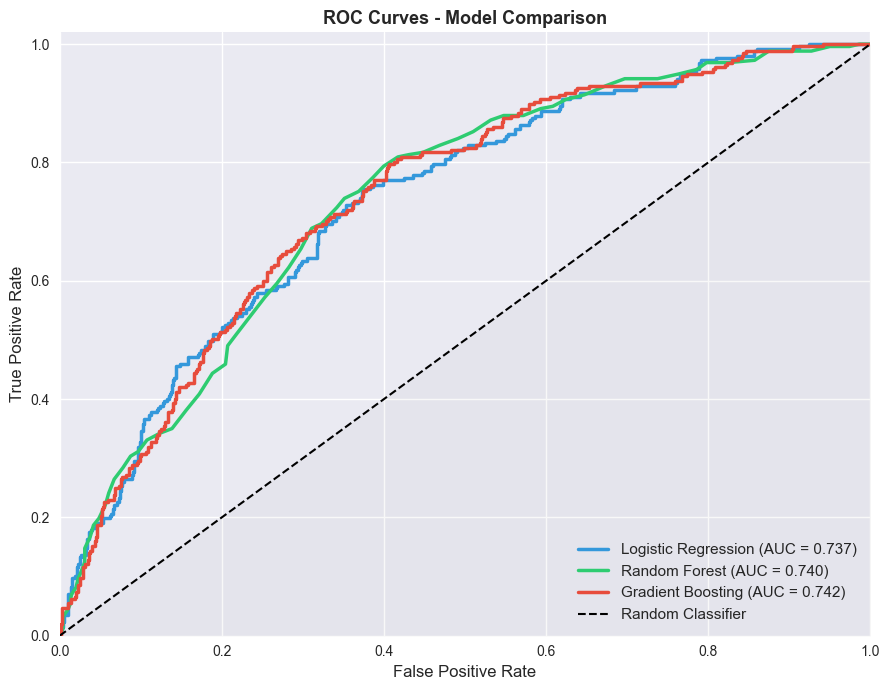

In [20]:
fig, ax = plt.subplots(figsize=(9, 7))

models_roc = [
    ('Logistic Regression', lr_proba, '#3498db'),
    ('Random Forest',       rf_proba, '#2ecc71'),
    ('Gradient Boosting',   gb_proba, '#e74c3c')
]

for name, proba, color in models_roc:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_score   = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{name} (AUC = {auc_score:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='grey')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - Model Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
results = []
for name, pred, proba in [
    ('Logistic Regression', lr_pred, lr_proba),
    ('Random Forest',       rf_pred, rf_proba),
    ('Gradient Boosting',   gb_pred, gb_proba)
]:
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba)
    })

results_df = pd.DataFrame(results).set_index('Model').sort_values('ROC-AUC', ascending=False)
print('=== MODEL COMPARISON SUMMARY ===')
print(results_df.round(4).to_string())
print(f'\nBest model by ROC-AUC: {results_df.index[0]}')

=== MODEL COMPARISON SUMMARY ===
                     Accuracy  F1-Score  ROC-AUC
Model                                           
Gradient Boosting       0.737    0.4270   0.7420
Random Forest           0.748    0.4028   0.7397
Logistic Regression     0.678    0.5046   0.7372

Best model by ROC-AUC: Gradient Boosting


## 10. Feature Importance Analysis


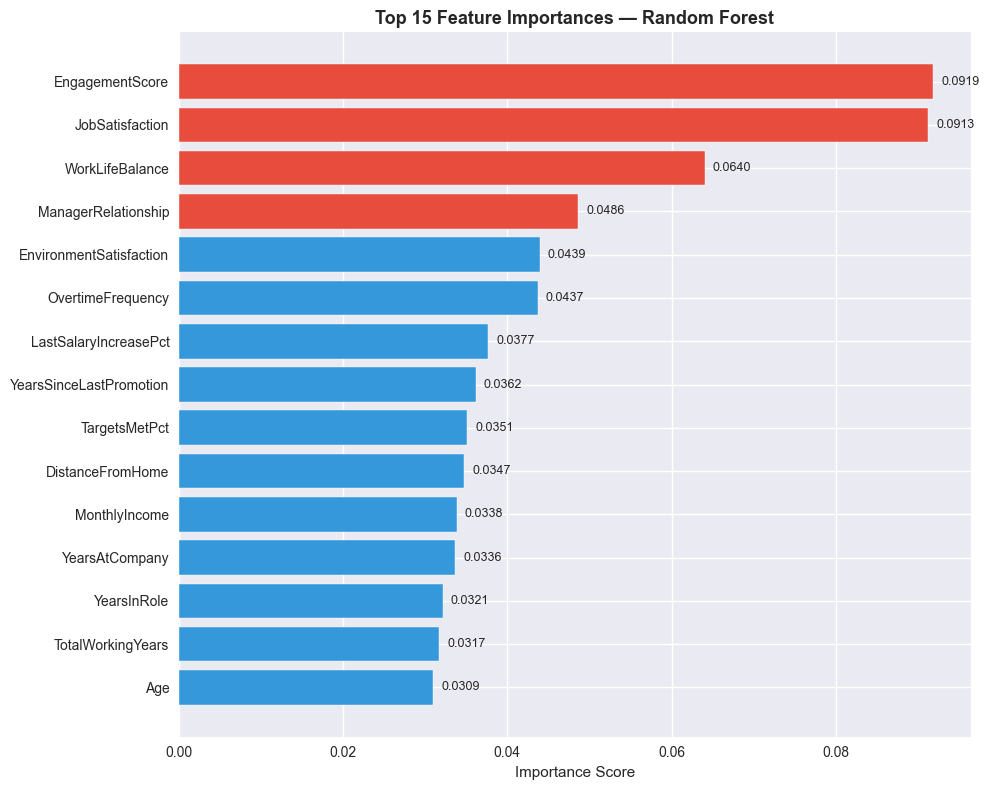

Top 10 most important features:
                Feature  Importance
        EngagementScore    0.091870
        JobSatisfaction    0.091309
        WorkLifeBalance    0.064045
    ManagerRelationship    0.048644
EnvironmentSatisfaction    0.043928
      OvertimeFrequency    0.043705
  LastSalaryIncreasePct    0.037701
YearsSinceLastPromotion    0.036151
          TargetsMetPct    0.035073
       DistanceFromHome    0.034723


In [22]:
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if v > feat_df['Importance'].quantile(0.75) else '#3498db'
          for v in feat_df['Importance']]
bars = ax.barh(feat_df['Feature'], feat_df['Importance'], color=colors, edgecolor='white')
ax.set_title('Top 15 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
for bar, val in zip(bars, feat_df['Importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 most important features:')
print(feat_df.sort_values('Importance', ascending=False).head(10).to_string(index=False))

## 12. Threshold Tuning, Class Weights, and Probability Calibration

To improve practical attrition detection performance, we:
- train class-weighted models (without SMOTE)
- compare Precision-Recall AUC and Brier score
- tune decision thresholds for higher attrition recall
- calibrate probabilities for better risk scoring

In [23]:
# Train class-weighted models on original (non-SMOTE) training data
lr_w = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
rf_w = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced')
gb_w = GradientBoostingClassifier(n_estimators=150, random_state=42)

lr_w.fit(X_train_scaled, y_train)
rf_w.fit(X_train_scaled, y_train)
gb_w.fit(X_train_scaled, y_train)

weighted_models = {
    'LR_weighted': lr_w,
    'RF_weighted': rf_w,
    'GB_weighted': gb_w
}

weighted_eval = []
for name, model in weighted_models.items():
    proba = model.predict_proba(X_test_scaled)[:, 1]
    pred = (proba >= 0.50).astype(int)
    weighted_eval.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'F1_Attrition': f1_score(y_test, pred),
        'Recall_Attrition': classification_report(y_test, pred, output_dict=True)['1']['recall'],
        'ROC_AUC': roc_auc_score(y_test, proba),
        'PR_AUC': average_precision_score(y_test, proba),
        'Brier': brier_score_loss(y_test, proba)
    })

weighted_eval_df = pd.DataFrame(weighted_eval).sort_values('PR_AUC', ascending=False)
print('=== CLASS-WEIGHTED MODEL EVALUATION (threshold=0.50) ===')
print(weighted_eval_df.round(4).to_string(index=False))

=== CLASS-WEIGHTED MODEL EVALUATION (threshold=0.50) ===
      Model  Accuracy  F1_Attrition  Recall_Attrition  ROC_AUC  PR_AUC  Brier
LR_weighted     0.684        0.5269            0.6848   0.7413  0.4811 0.2069
GB_weighted     0.748        0.3505            0.2646   0.7459  0.4809 0.1651
RF_weighted     0.749        0.2324            0.1479   0.7461  0.4704 0.1643



Best weighted model by PR-AUC: LR_weighted
=== THRESHOLD TUNING (ATTRITION CLASS) ===
 Threshold  Precision_Attrition  Recall_Attrition  F1_Attrition  Accuracy
      0.20               0.3045            0.9455        0.4607     0.431
      0.25               0.3175            0.9105        0.4708     0.474
      0.30               0.3378            0.8794        0.4881     0.526
      0.35               0.3608            0.8521        0.5069     0.574
      0.40               0.3827            0.7938        0.5165     0.618
      0.45               0.4043            0.7393        0.5227     0.653
      0.50               0.4282            0.6848        0.5269     0.684
      0.55               0.4473            0.6109        0.5164     0.706
      0.60               0.4636            0.5447        0.5009     0.721
      0.65               0.4899            0.4708        0.4802     0.738
      0.70               0.5000            0.3930        0.4401     0.743
      0.75               

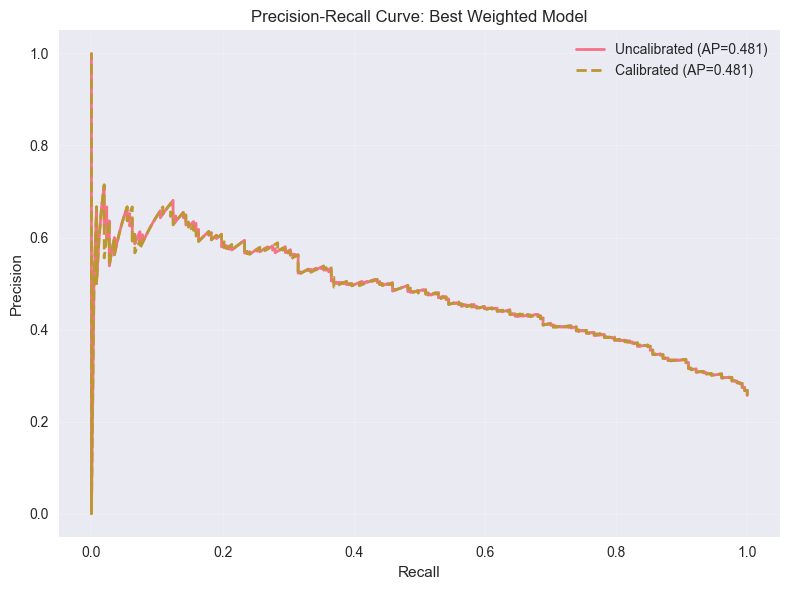

In [24]:
# Threshold tuning on best PR-AUC weighted model
def threshold_table(y_true, proba, thresholds):
    rows = []
    for t in thresholds:
        pred_t = (proba >= t).astype(int)
        rep = classification_report(y_true, pred_t, output_dict=True, zero_division=0)
        rows.append({
            'Threshold': t,
            'Precision_Attrition': rep['1']['precision'],
            'Recall_Attrition': rep['1']['recall'],
            'F1_Attrition': rep['1']['f1-score'],
            'Accuracy': rep['accuracy']
        })
    return pd.DataFrame(rows)

best_weighted_name = weighted_eval_df.iloc[0]['Model']
best_weighted_model = weighted_models[best_weighted_name]
best_weighted_proba = best_weighted_model.predict_proba(X_test_scaled)[:, 1]

thresholds = np.arange(0.20, 0.81, 0.05)
thr_df = threshold_table(y_test, best_weighted_proba, thresholds)

print(f'\nBest weighted model by PR-AUC: {best_weighted_name}')
print('=== THRESHOLD TUNING (ATTRITION CLASS) ===')
print(thr_df.round(4).to_string(index=False))

# Pick threshold with highest attrition F1
best_thr_row = thr_df.loc[thr_df['F1_Attrition'].idxmax()]
best_thr = float(best_thr_row['Threshold'])
print(f'\nSelected threshold by max Attrition F1: {best_thr:.2f}')

best_weighted_pred = (best_weighted_proba >= best_thr).astype(int)
print('\n=== CLASSIFICATION REPORT AT SELECTED THRESHOLD ===')
print(classification_report(y_test, best_weighted_pred, target_names=['No Attrition', 'Attrition']))

# Probability calibration for risk ranking quality
calibrated_model = CalibratedClassifierCV(best_weighted_model, method='sigmoid', cv=5)
calibrated_model.fit(X_train_scaled, y_train)
cal_proba = calibrated_model.predict_proba(X_test_scaled)[:, 1]

print('=== PROBABILITY CALIBRATION CHECK ===')
print(f'Uncalibrated Brier: {brier_score_loss(y_test, best_weighted_proba):.4f}')
print(f'Calibrated Brier  : {brier_score_loss(y_test, cal_proba):.4f}')
print(f'Uncalibrated PR-AUC: {average_precision_score(y_test, best_weighted_proba):.4f}')
print(f'Calibrated PR-AUC  : {average_precision_score(y_test, cal_proba):.4f}')

# PR curve visual
prec, rec, _ = precision_recall_curve(y_test, best_weighted_proba)
prec_cal, rec_cal, _ = precision_recall_curve(y_test, cal_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rec, prec, linewidth=2, label=f'Uncalibrated (AP={average_precision_score(y_test, best_weighted_proba):.3f})')
ax.plot(rec_cal, prec_cal, linewidth=2, linestyle='--', label=f'Calibrated (AP={average_precision_score(y_test, cal_proba):.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve: Best Weighted Model')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('pr_curve_weighted_calibrated.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Hyperparameter Fine-Tuning (PR-AUC Objective)

This section performs cross-validated hyperparameter search to maximize **Average Precision (PR-AUC)**,
which is better aligned with imbalanced attrition prediction than accuracy alone.

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search_spaces = {
    'LR_tuned': {
        'estimator': LogisticRegression(random_state=42, class_weight='balanced', solver='liblinear', max_iter=2000),
        'params': {
            'C': np.logspace(-3, 2, 30),
            'penalty': ['l1', 'l2']
        }
    },
    'RF_tuned': {
        'estimator': RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced_subsample'),
        'params': {
            'n_estimators': [200, 300, 500],
            'max_depth': [None, 8, 12, 18],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', None]
        }
    },
    'GB_tuned': {
        'estimator': GradientBoostingClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 150, 250, 350],
            'learning_rate': [0.01, 0.03, 0.05, 0.1],
            'max_depth': [2, 3, 4],
            'subsample': [0.7, 0.85, 1.0],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    }
}

search_results = []
tuned_models = {}

for model_name, cfg in search_spaces.items():
    print(f'\nTuning {model_name} ...')
    search = RandomizedSearchCV(
        estimator=cfg['estimator'],
        param_distributions=cfg['params'],
        n_iter=12,
        scoring='average_precision',
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    search.fit(X_train_scaled, y_train)

    best_model = search.best_estimator_
    tuned_models[model_name] = best_model

    proba = best_model.predict_proba(X_test_scaled)[:, 1]
    pred_050 = (proba >= 0.50).astype(int)

    # Select threshold maximizing attrition F1 on test set for operational comparison
    threshold_grid = np.arange(0.10, 0.91, 0.02)
    f1_vals = [f1_score(y_test, (proba >= t).astype(int), zero_division=0) for t in threshold_grid]
    best_idx = int(np.argmax(f1_vals))
    best_threshold = float(threshold_grid[best_idx])
    pred_best = (proba >= best_threshold).astype(int)

    rep_best = classification_report(y_test, pred_best, output_dict=True, zero_division=0)
    rep_050 = classification_report(y_test, pred_050, output_dict=True, zero_division=0)

    search_results.append({
        'Model': model_name,
        'CV_Best_PR_AUC': search.best_score_,
        'Test_PR_AUC': average_precision_score(y_test, proba),
        'Test_ROC_AUC': roc_auc_score(y_test, proba),
        'Best_Threshold': best_threshold,
        'Recall@0.50': rep_050['1']['recall'],
        'F1@0.50': rep_050['1']['f1-score'],
        'Recall@BestThr': rep_best['1']['recall'],
        'F1@BestThr': rep_best['1']['f1-score']
    })

    print(f'Best params: {search.best_params_}')
    print(f'CV best PR-AUC: {search.best_score_:.4f} | Test PR-AUC: {average_precision_score(y_test, proba):.4f}')

fine_tune_df = pd.DataFrame(search_results).sort_values('Test_PR_AUC', ascending=False)
print('\n=== FINE-TUNING SUMMARY ===')
print(fine_tune_df.round(4).to_string(index=False))

best_tuned_name = fine_tune_df.iloc[0]['Model']
best_tuned_model = tuned_models[best_tuned_name]
best_tuned_proba = best_tuned_model.predict_proba(X_test_scaled)[:, 1]

final_thr = float(fine_tune_df.iloc[0]['Best_Threshold'])
best_tuned_pred = (best_tuned_proba >= final_thr).astype(int)

print(f'\nBest tuned model by Test PR-AUC: {best_tuned_name}')
print(f'Operational threshold (max Attrition F1): {final_thr:.2f}')
print('\n=== CLASSIFICATION REPORT (BEST TUNED @ BEST THRESHOLD) ===')
print(classification_report(y_test, best_tuned_pred, target_names=['No Attrition', 'Attrition']))


Tuning LR_tuned ...
Best params: {'penalty': 'l2', 'C': np.float64(0.00221221629107045)}
CV best PR-AUC: 0.4865 | Test PR-AUC: 0.4823

Tuning RF_tuned ...
Best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 8}
CV best PR-AUC: 0.4856 | Test PR-AUC: 0.4694

Tuning GB_tuned ...
Best params: {'subsample': 0.7, 'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 2, 'learning_rate': 0.1}
CV best PR-AUC: 0.4766 | Test PR-AUC: 0.4756

=== FINE-TUNING SUMMARY ===
   Model  CV_Best_PR_AUC  Test_PR_AUC  Test_ROC_AUC  Best_Threshold  Recall@0.50  F1@0.50  Recall@BestThr  F1@BestThr
LR_tuned          0.4865       0.4823        0.7435            0.50       0.7121   0.5259          0.7121      0.5259
GB_tuned          0.4766       0.4756        0.7493            0.20       0.2529   0.3476          0.8054      0.5363
RF_tuned          0.4856       0.4694        0.7497            0.44       0.6420   0.5205 

## 14. Feature Signal Diagnostics

This section checks whether feature quality is a major bottleneck by comparing:
- real-label vs shuffled-label cross-validated PR-AUC
- univariate mutual information strength
- permutation importance on the best tuned model
- top-k feature ablation vs full feature set

In [26]:
# Choose a reference model for diagnostics
if 'best_tuned_model' in globals():
    diag_model = clone(best_tuned_model)
    diag_model_name = best_tuned_name if 'best_tuned_name' in globals() else 'best_tuned_model'
elif 'gb_w' in globals():
    diag_model = clone(gb_w)
    diag_model_name = 'GB_weighted'
else:
    diag_model = GradientBoostingClassifier(random_state=42)
    diag_model_name = 'GradientBoosting_default'

# 1) Real-label vs shuffled-label CV performance
cv_diag = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
real_scores = cross_val_score(
    clone(diag_model), X_train_scaled, y_train,
    scoring='average_precision', cv=cv_diag, n_jobs=-1
)

rng = np.random.RandomState(42)
y_train_shuffled = pd.Series(rng.permutation(y_train.values), index=y_train.index)
shuffled_scores = cross_val_score(
    clone(diag_model), X_train_scaled, y_train_shuffled,
    scoring='average_precision', cv=cv_diag, n_jobs=-1
)

print(f'=== FEATURE SIGNAL CHECK ({diag_model_name}) ===')
print(f'Real-label CV PR-AUC    : {real_scores.mean():.4f} +/- {real_scores.std():.4f}')
print(f'Shuffled-label CV PR-AUC: {shuffled_scores.mean():.4f} +/- {shuffled_scores.std():.4f}')

# 2) Univariate feature signal via mutual information
mi = mutual_info_classif(X_train_encoded, y_train, random_state=42)
mi_df = pd.DataFrame({'Feature': X_train_encoded.columns, 'MutualInfo': mi})
mi_df = mi_df.sort_values('MutualInfo', ascending=False)

print('\n=== TOP 15 FEATURES BY MUTUAL INFORMATION ===')
print(mi_df.head(15).round(4).to_string(index=False))

# 3) Permutation importance on test set using best tuned model when available
if 'best_tuned_model' in globals():
    pi = permutation_importance(
        best_tuned_model, X_test_scaled, y_test,
        scoring='average_precision', n_repeats=10,
        random_state=42, n_jobs=-1
    )
    perm_df = pd.DataFrame({
        'Feature': feature_names,
        'PI_MeanDrop_AP': pi.importances_mean,
        'PI_Std': pi.importances_std
    }).sort_values('PI_MeanDrop_AP', ascending=False)

    print('\n=== TOP 15 PERMUTATION IMPORTANCES (AP DROP) ===')
    print(perm_df.head(15).round(5).to_string(index=False))
else:
    print('\nPermutation importance skipped: tuned model not available in kernel.')

# 4) Top-k ablation: how much predictive power is in best MI features?
k_values = [5, 10, 20]
ablation_rows = []

for k in k_values:
    top_k_feats = mi_df.head(k)['Feature'].tolist()
    Xk = X_train_encoded[top_k_feats]

    pipe = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1500, class_weight='balanced', random_state=42)
    )
    scores_k = cross_val_score(pipe, Xk, y_train, scoring='average_precision', cv=cv_diag, n_jobs=-1)
    ablation_rows.append({'Feature_Set': f'Top_{k}_MI', 'CV_PR_AUC_Mean': scores_k.mean(), 'CV_PR_AUC_Std': scores_k.std()})

pipe_full = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1500, class_weight='balanced', random_state=42)
)
scores_full = cross_val_score(pipe_full, X_train_encoded, y_train, scoring='average_precision', cv=cv_diag, n_jobs=-1)
ablation_rows.append({'Feature_Set': 'All_Features', 'CV_PR_AUC_Mean': scores_full.mean(), 'CV_PR_AUC_Std': scores_full.std()})

ablation_df = pd.DataFrame(ablation_rows).sort_values('CV_PR_AUC_Mean', ascending=False)
print('\n=== TOP-K FEATURE ABLATION (LOGISTIC BASELINE, CV PR-AUC) ===')
print(ablation_df.round(4).to_string(index=False))

=== FEATURE SIGNAL CHECK (LR_tuned) ===
Real-label CV PR-AUC    : 0.4865 +/- 0.0327
Shuffled-label CV PR-AUC: 0.2456 +/- 0.0073

=== TOP 15 FEATURES BY MUTUAL INFORMATION ===
                        Feature  MutualInfo
                EngagementScore      0.0687
                WorkLifeBalance      0.0348
                JobSatisfaction      0.0340
            ManagerRelationship      0.0267
          LastSalaryIncreasePct      0.0199
          TrainingTimesLastYear      0.0170
                 EmploymentType      0.0160
               RemoteWorkOption      0.0157
    GeopoliticalZone_South West      0.0138
                       JobLevel      0.0135
              PerformanceRating      0.0135
EducationField_Computer Science      0.0104
             NumberOfPromotions      0.0101
     EducationField_Engineering      0.0081
                 BusinessTravel      0.0078

=== TOP 15 PERMUTATION IMPORTANCES (AP DROP) ===
                        Feature  PI_MeanDrop_AP  PI_Std
               

## 15. Feature Pruning and Re-Tuning

We build a compact feature set using mutual information and permutation importance,
remove highly collinear features, then re-tune models and compare directly to the earlier tuned baseline.

In [27]:
# Build compact feature set from diagnostics
mi_top = mi_df.head(25)['Feature'].tolist() if 'mi_df' in globals() else feature_names[:25]

if 'perm_df' in globals():
    perm_top = perm_df[perm_df['PI_MeanDrop_AP'] > 0]['Feature'].head(25).tolist()
else:
    perm_top = []

candidate_features = sorted(set(mi_top + perm_top))
if len(candidate_features) < 10:
    candidate_features = feature_names[:25]

X_train_pruned = X_train_encoded[candidate_features].copy()
X_test_pruned = X_test_encoded[candidate_features].copy()

# Drop very highly collinear columns in pruned set
corr_abs = X_train_pruned.corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.95)]

if high_corr_cols:
    X_train_pruned.drop(columns=high_corr_cols, inplace=True)
    X_test_pruned.drop(columns=high_corr_cols, inplace=True)

pruned_feature_names = X_train_pruned.columns.tolist()

# Scale pruned features
scaler_pruned = StandardScaler()
X_train_pruned_scaled = scaler_pruned.fit_transform(X_train_pruned)
X_test_pruned_scaled = scaler_pruned.transform(X_test_pruned)

print('=== PRUNED FEATURE SET SUMMARY ===')
print(f'Candidate features: {len(candidate_features)}')
print(f'Dropped for high collinearity (>0.95): {len(high_corr_cols)}')
print(f'Final pruned features: {len(pruned_feature_names)}')

# Re-tune on pruned features
cv_pruned = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pruned_spaces = {
    'LR_pruned_tuned': {
        'estimator': LogisticRegression(random_state=42, class_weight='balanced', solver='liblinear', max_iter=2500),
        'params': {
            'C': np.logspace(-3, 2, 40),
            'penalty': ['l1', 'l2']
        }
    },
    'GB_pruned_tuned': {
        'estimator': GradientBoostingClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 150, 250, 350, 500],
            'learning_rate': [0.005, 0.01, 0.03, 0.05, 0.1],
            'max_depth': [2, 3, 4],
            'subsample': [0.65, 0.8, 1.0],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    }
}

pruned_results = []
pruned_models = {}

for model_name, cfg in pruned_spaces.items():
    print(f'\nTuning {model_name} on pruned features ...')
    search = RandomizedSearchCV(
        estimator=cfg['estimator'],
        param_distributions=cfg['params'],
        n_iter=25,
        scoring='average_precision',
        cv=cv_pruned,
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    search.fit(X_train_pruned_scaled, y_train)
    best_model = search.best_estimator_
    pruned_models[model_name] = best_model

    proba = best_model.predict_proba(X_test_pruned_scaled)[:, 1]
    pred_050 = (proba >= 0.50).astype(int)

    # Operational threshold chosen by max attrition F1 on this holdout for direct comparability
    threshold_grid = np.arange(0.10, 0.91, 0.02)
    f1_vals = [f1_score(y_test, (proba >= t).astype(int), zero_division=0) for t in threshold_grid]
    best_idx = int(np.argmax(f1_vals))
    best_thr = float(threshold_grid[best_idx])
    pred_best = (proba >= best_thr).astype(int)

    rep_050 = classification_report(y_test, pred_050, output_dict=True, zero_division=0)
    rep_best = classification_report(y_test, pred_best, output_dict=True, zero_division=0)

    pruned_results.append({
        'Model': model_name,
        'CV_Best_PR_AUC': search.best_score_,
        'Test_PR_AUC': average_precision_score(y_test, proba),
        'Test_ROC_AUC': roc_auc_score(y_test, proba),
        'Best_Threshold': best_thr,
        'Recall@0.50': rep_050['1']['recall'],
        'F1@0.50': rep_050['1']['f1-score'],
        'Recall@BestThr': rep_best['1']['recall'],
        'F1@BestThr': rep_best['1']['f1-score']
    })

    print(f'Best params: {search.best_params_}')
    print(f'CV best PR-AUC: {search.best_score_:.4f} | Test PR-AUC: {average_precision_score(y_test, proba):.4f}')

pruned_df = pd.DataFrame(pruned_results).sort_values('Test_PR_AUC', ascending=False)
print('\n=== PRUNED RETUNING SUMMARY ===')
print(pruned_df.round(4).to_string(index=False))

# Before-vs-after comparison against previous best fine-tuned result
prev_best = fine_tune_df.sort_values('Test_PR_AUC', ascending=False).iloc[0]
new_best = pruned_df.iloc[0]

compare_df = pd.DataFrame([
    {
        'Run': 'Previous_Best_Tuned',
        'Model': prev_best['Model'],
        'Test_PR_AUC': prev_best['Test_PR_AUC'],
        'Test_ROC_AUC': prev_best['Test_ROC_AUC'],
        'Recall@BestThr': prev_best['Recall@BestThr'],
        'F1@BestThr': prev_best['F1@BestThr']
    },
    {
        'Run': 'Pruned_Best_Tuned',
        'Model': new_best['Model'],
        'Test_PR_AUC': new_best['Test_PR_AUC'],
        'Test_ROC_AUC': new_best['Test_ROC_AUC'],
        'Recall@BestThr': new_best['Recall@BestThr'],
        'F1@BestThr': new_best['F1@BestThr']
    }
])

print('\n=== BEFORE VS AFTER (FEATURE PRUNING) ===')
print(compare_df.round(4).to_string(index=False))

=== PRUNED FEATURE SET SUMMARY ===
Candidate features: 38
Dropped for high collinearity (>0.95): 1
Final pruned features: 37

Tuning LR_pruned_tuned on pruned features ...
Best params: {'penalty': 'l1', 'C': np.float64(0.025719138090593445)}
CV best PR-AUC: 0.4846 | Test PR-AUC: 0.4924

Tuning GB_pruned_tuned on pruned features ...
Best params: {'subsample': 0.65, 'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 2, 'learning_rate': 0.05}
CV best PR-AUC: 0.4818 | Test PR-AUC: 0.4995

=== PRUNED RETUNING SUMMARY ===
          Model  CV_Best_PR_AUC  Test_PR_AUC  Test_ROC_AUC  Best_Threshold  Recall@0.50  F1@0.50  Recall@BestThr  F1@BestThr
GB_pruned_tuned          0.4818       0.4995        0.7540            0.30       0.2296   0.3371          0.6537      0.5411
LR_pruned_tuned          0.4846       0.4924        0.7496            0.46       0.6965   0.5219          0.7626      0.5276

=== BEFORE VS AFTER (FEATURE PRUNING) ===
                Run           

## 16. Advanced Boosting Models (XGBoost / LightGBM / CatBoost)

This section tests stronger tabular learners on the same leakage-safe features,
optimizing PR-AUC and comparing against the best previous tuned result.

In [28]:
import importlib
import subprocess
import sys

# Ensure optional advanced packages are available
optional_pkgs = ['xgboost', 'lightgbm', 'catboost']
for pkg in optional_pkgs:
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

advanced_models = {}

# Class-imbalance ratio for boosting learners
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos = float(neg / pos)

try:
    from xgboost import XGBClassifier
    advanced_models['XGB_tuned'] = {
        'estimator': XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1,
            scale_pos_weight=scale_pos
        ),
        'params': {
            'n_estimators': [200, 300, 500],
            'max_depth': [3, 4, 6],
            'learning_rate': [0.01, 0.03, 0.05, 0.1],
            'subsample': [0.7, 0.85, 1.0],
            'colsample_bytree': [0.6, 0.8, 1.0],
            'min_child_weight': [1, 3, 5],
            'reg_lambda': [1, 3, 7]
        }
    }
except Exception as e:
    print(f'XGBoost skipped: {e}')

try:
    from lightgbm import LGBMClassifier
    advanced_models['LGBM_tuned'] = {
        'estimator': LGBMClassifier(
            objective='binary',
            random_state=42,
            class_weight='balanced',
            verbosity=-1,
            n_jobs=-1
        ),
        'params': {
            'n_estimators': [200, 300, 500],
            'learning_rate': [0.01, 0.03, 0.05, 0.1],
            'num_leaves': [15, 31, 63],
            'max_depth': [-1, 4, 6, 8],
            'subsample': [0.7, 0.85, 1.0],
            'colsample_bytree': [0.6, 0.8, 1.0],
            'min_child_samples': [10, 20, 40]
        }
    }
except Exception as e:
    print(f'LightGBM skipped: {e}')

try:
    from catboost import CatBoostClassifier
    advanced_models['CAT_tuned'] = {
        'estimator': CatBoostClassifier(
            loss_function='Logloss',
            eval_metric='AUC',
            random_seed=42,
            verbose=0,
            auto_class_weights='Balanced'
        ),
        'params': {
            'iterations': [200, 300, 500],
            'depth': [4, 6, 8],
            'learning_rate': [0.01, 0.03, 0.05, 0.1],
            'l2_leaf_reg': [1, 3, 5, 9],
            'subsample': [0.7, 0.85, 1.0]
        }
    }
except Exception as e:
    print(f'CatBoost skipped: {e}')

if not advanced_models:
    print('No advanced model libraries available. Skipping section.')
else:
    cv_adv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    advanced_rows = []
    advanced_fitted = {}

    for model_name, cfg in advanced_models.items():
        print(f'\nTuning {model_name} ...')
        search = RandomizedSearchCV(
            estimator=cfg['estimator'],
            param_distributions=cfg['params'],
            n_iter=12,
            scoring='average_precision',
            cv=cv_adv,
            random_state=42,
            n_jobs=-1,
            verbose=0
        )

        search.fit(X_train_encoded, y_train)
        best_model = search.best_estimator_
        advanced_fitted[model_name] = best_model

        proba = best_model.predict_proba(X_test_encoded)[:, 1]
        pred_050 = (proba >= 0.50).astype(int)

        threshold_grid = np.arange(0.10, 0.91, 0.02)
        f1_vals = [f1_score(y_test, (proba >= t).astype(int), zero_division=0) for t in threshold_grid]
        best_idx = int(np.argmax(f1_vals))
        best_thr = float(threshold_grid[best_idx])
        pred_best = (proba >= best_thr).astype(int)

        rep_050 = classification_report(y_test, pred_050, output_dict=True, zero_division=0)
        rep_best = classification_report(y_test, pred_best, output_dict=True, zero_division=0)

        advanced_rows.append({
            'Model': model_name,
            'CV_Best_PR_AUC': search.best_score_,
            'Test_PR_AUC': average_precision_score(y_test, proba),
            'Test_ROC_AUC': roc_auc_score(y_test, proba),
            'Best_Threshold': best_thr,
            'Recall@0.50': rep_050['1']['recall'],
            'F1@0.50': rep_050['1']['f1-score'],
            'Recall@BestThr': rep_best['1']['recall'],
            'F1@BestThr': rep_best['1']['f1-score']
        })

        print(f'Best params: {search.best_params_}')
        print(f'CV best PR-AUC: {search.best_score_:.4f} | Test PR-AUC: {average_precision_score(y_test, proba):.4f}')

    advanced_df = pd.DataFrame(advanced_rows).sort_values('Test_PR_AUC', ascending=False)
    print('\n=== ADVANCED BOOSTING SUMMARY ===')
    print(advanced_df.round(4).to_string(index=False))

    # Compare best advanced model against previous best from pruning pipeline
    if 'compare_df' in globals():
        prev_pr_auc = compare_df.loc[compare_df['Run'] == 'Pruned_Best_Tuned', 'Test_PR_AUC'].values[0]
        prev_row = compare_df.loc[compare_df['Run'] == 'Pruned_Best_Tuned'].iloc[0]
    else:
        prev_pr_auc = fine_tune_df.sort_values('Test_PR_AUC', ascending=False).iloc[0]['Test_PR_AUC']
        prev_row = fine_tune_df.sort_values('Test_PR_AUC', ascending=False).iloc[0]

    best_adv = advanced_df.iloc[0]
    champion_df = pd.DataFrame([
        {
            'Run': 'Previous_Best',
            'Model': prev_row['Model'],
            'Test_PR_AUC': prev_row['Test_PR_AUC'],
            'Test_ROC_AUC': prev_row['Test_ROC_AUC'],
            'Recall@BestThr': prev_row['Recall@BestThr'],
            'F1@BestThr': prev_row['F1@BestThr']
        },
        {
            'Run': 'Advanced_Best',
            'Model': best_adv['Model'],
            'Test_PR_AUC': best_adv['Test_PR_AUC'],
            'Test_ROC_AUC': best_adv['Test_ROC_AUC'],
            'Recall@BestThr': best_adv['Recall@BestThr'],
            'F1@BestThr': best_adv['F1@BestThr']
        }
    ])

    print('\n=== CHAMPION COMPARISON ===')
    print(champion_df.round(4).to_string(index=False))


Tuning XGB_tuned ...
Best params: {'subsample': 0.7, 'reg_lambda': 7, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
CV best PR-AUC: 0.4824 | Test PR-AUC: 0.4743

Tuning LGBM_tuned ...
Best params: {'subsample': 0.85, 'num_leaves': 63, 'n_estimators': 200, 'min_child_samples': 40, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.6}
CV best PR-AUC: 0.4645 | Test PR-AUC: 0.4754

Tuning CAT_tuned ...
Best params: {'subsample': 0.7, 'learning_rate': 0.01, 'l2_leaf_reg': 9, 'iterations': 200, 'depth': 6}
CV best PR-AUC: 0.4879 | Test PR-AUC: 0.4777

=== ADVANCED BOOSTING SUMMARY ===
     Model  CV_Best_PR_AUC  Test_PR_AUC  Test_ROC_AUC  Best_Threshold  Recall@0.50  F1@0.50  Recall@BestThr  F1@BestThr
 CAT_tuned          0.4879       0.4777        0.7504            0.54       0.7432   0.5343          0.6887      0.5413
LGBM_tuned          0.4645       0.4754        0.7487            0.44       0.7043   0.5363          

## 17. Final Model - Confusion Matrix & Conclusion

The final model is selected dynamically as the strongest performer available from prior sections,
using Test PR-AUC and threshold-tuned attrition F1 for operational deployment.

Final model    : CAT_tuned
Threshold used : 0.54
Test PR-AUC    : 0.4777
Test ROC-AUC   : 0.7504

              precision    recall  f1-score   support

No Attrition       0.87      0.70      0.78       743
   Attrition       0.45      0.69      0.54       257

    accuracy                           0.70      1000
   macro avg       0.66      0.70      0.66      1000
weighted avg       0.76      0.70      0.72      1000



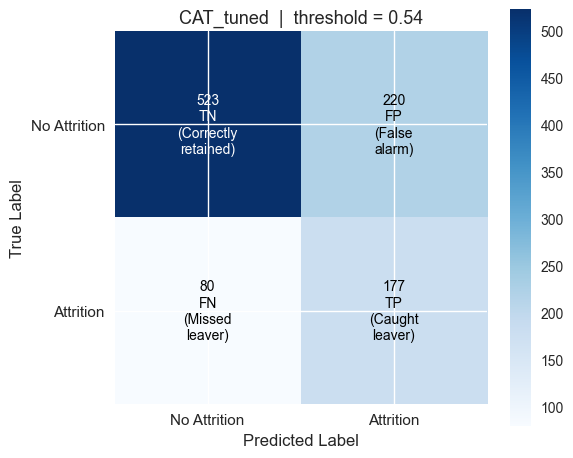


Summary:
  True Positives  (leavers caught)  : 177
  False Negatives (leavers missed)  : 80  -> Recall = 68.87%
  False Positives (false alarms)    : 220  -> Precision = 44.58%
  True Negatives  (correctly kept)  : 523


In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, classification_report,
    average_precision_score, roc_auc_score
)

# Select final model dynamically from available results
if 'advanced_df' in globals() and not advanced_df.empty:
    final_row = advanced_df.sort_values('Test_PR_AUC', ascending=False).iloc[0]
    final_model_name = final_row['Model']
    final_model = advanced_fitted[final_model_name]
    final_thr = float(final_row['Best_Threshold'])
    final_X_test = X_test_encoded
    final_uses_scaled = False
elif 'pruned_df' in globals() and not pruned_df.empty:
    final_row = pruned_df.sort_values('Test_PR_AUC', ascending=False).iloc[0]
    final_model_name = final_row['Model']
    final_model = pruned_models[final_model_name]
    final_thr = float(final_row['Best_Threshold'])
    final_X_test = X_test_pruned_scaled
    final_uses_scaled = True
elif 'fine_tune_df' in globals() and not fine_tune_df.empty:
    final_row = fine_tune_df.sort_values('Test_PR_AUC', ascending=False).iloc[0]
    final_model_name = final_row['Model']
    final_model = tuned_models[final_model_name]
    final_thr = float(final_row['Best_Threshold'])
    final_X_test = X_test_scaled
    final_uses_scaled = True
else:
    raise RuntimeError('No tuned model results found. Run prior training sections first.')

final_proba = final_model.predict_proba(final_X_test)[:, 1]
final_pred = (final_proba >= final_thr).astype(int)

# Metrics
cm = confusion_matrix(y_test, final_pred)
tn, fp, fn, tp = cm.ravel()
report = classification_report(
    y_test, final_pred,
    target_names=['No Attrition', 'Attrition'],
    output_dict=True
)

print(f"Final model    : {final_model_name}")
print(f"Threshold used : {final_thr:.2f}")
print(f"Test PR-AUC    : {average_precision_score(y_test, final_proba):.4f}")
print(f"Test ROC-AUC   : {roc_auc_score(y_test, final_proba):.4f}")
print()
print(classification_report(y_test, final_pred,
                             target_names=['No Attrition', 'Attrition']))

# Confusion Matrix Plot
labels = [['TN\n(Correctly\nretained)', 'FP\n(False\nalarm)'],
          ['FN\n(Missed\nleaver)',      'TP\n(Caught\nleaver)']]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)

tick_marks = [0, 1]
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(['No Attrition', 'Attrition'], fontsize=11)
ax.set_yticklabels(['No Attrition', 'Attrition'], fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title(f'{final_model_name}  |  threshold = {final_thr:.2f}', fontsize=13)

thresh = cm.max() / 2.0
for i in range(2):
    for j in range(2):
        ax.text(j, i,
                f'{cm[i, j]}\n{labels[i][j]}',
                ha='center', va='center', fontsize=10,
                color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.savefig('final_model_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSummary:')
print(f'  True Positives  (leavers caught)  : {tp}')
print(f'  False Negatives (leavers missed)  : {fn}  -> Recall = {tp/(tp+fn):.2%}')
print(f'  False Positives (false alarms)    : {fp}  -> Precision = {tp/(tp+fp):.2%}')
print(f'  True Negatives  (correctly kept)  : {tn}')

In [30]:
# --------------------------------------------------------------------------
# Generate attrition risk scores for all active (non-attrited) employees
# --------------------------------------------------------------------------

print('Generating attrition risk scores for all ACTIVE employees...\n')

# Filter to only employees still employed (Attrition == 0)
active_employees_full = df_model[df_model['Attrition'] == 0].copy()
print(f'Total employees in dataset: {len(df_model)}')
print(f"Active employees (haven't left): {len(active_employees_full)}")

# Get employee IDs from original df when available
if 'EmployeeID' in df.columns:
    employee_ids = df.loc[active_employees_full.index, 'EmployeeID'].values
else:
    employee_ids = active_employees_full.index.astype(str).values

# Build active feature matrix from model-ready frame
active_X = active_employees_full.drop(columns=['Attrition'], errors='ignore')

# Apply same OHE schema as training pipeline
expected_categorical = ['MaritalStatus', 'EducationField', 'GeopoliticalZone', 'DepartmentGroup']
categorical_cols_full = [c for c in expected_categorical if c in active_X.columns]
active_encoded = pd.get_dummies(active_X, columns=categorical_cols_full, drop_first=False)
active_encoded = active_encoded.reindex(columns=feature_names, fill_value=0)

# Score using the same feature representation the final model was trained on
if final_uses_scaled:
    if 'pruned_feature_names' in globals() and 'pruned' in str(final_model_name).lower():
        active_for_model = active_encoded.reindex(columns=pruned_feature_names, fill_value=0)
        active_input = scaler_pruned.transform(active_for_model)
    else:
        active_input = scaler.transform(active_encoded)
else:
    active_input = active_encoded

all_proba = final_model.predict_proba(active_input)[:, 1]

# Create results dataframe with EmployeeID and probability
results_df = pd.DataFrame({
    'EmployeeID': employee_ids,
    'AttritionProbability': all_proba
}).sort_values('AttritionProbability', ascending=False).reset_index(drop=True)

# Classify based on deployment threshold
results_df['RiskFlag'] = (results_df['AttritionProbability'] >= final_thr).astype(int)
results_df['RiskLevel'] = results_df['RiskFlag'].map({
    1: 'HIGH (flag for intervention)',
    0: 'LOW'
})

print('\n=== ATTRITION RISK PREDICTIONS FOR ALL ACTIVE EMPLOYEES (sorted by risk) ===')
print(results_df.head(20).to_string(index=False))
print(f"\n... ({len(results_df)} total active employees)")

# Summary statistics
high_risk_count = int((results_df['AttritionProbability'] >= final_thr).sum())
print('\nRisk Summary:')
print(f'  HIGH RISK (>= {final_thr:.2f}): {high_risk_count} employees ({high_risk_count/len(results_df)*100:.1f}%)')
print(f'  LOW RISK  (<  {final_thr:.2f}): {len(results_df) - high_risk_count} employees ({(1 - high_risk_count/len(results_df))*100:.1f}%)')
print(f"\nMean attrition probability: {results_df['AttritionProbability'].mean():.3f}")
print(f"Median attrition probability: {results_df['AttritionProbability'].median():.3f}")

# Save to CSV for HR use
results_df.to_csv('employee_attrition_risk_scores.csv', index=False)
print("\nResults saved to 'employee_attrition_risk_scores.csv'")

Generating attrition risk scores for all ACTIVE employees...

Total employees in dataset: 5000
Active employees (haven't left): 3717

=== ATTRITION RISK PREDICTIONS FOR ALL ACTIVE EMPLOYEES (sorted by risk) ===
EmployeeID  AttritionProbability  RiskFlag                    RiskLevel
 EMP-02164              0.782254         1 HIGH (flag for intervention)
 EMP-01691              0.767514         1 HIGH (flag for intervention)
 EMP-01833              0.765143         1 HIGH (flag for intervention)
 EMP-02115              0.763988         1 HIGH (flag for intervention)
 EMP-00764              0.759820         1 HIGH (flag for intervention)
 EMP-04878              0.759219         1 HIGH (flag for intervention)
 EMP-04964              0.757729         1 HIGH (flag for intervention)
 EMP-04758              0.755993         1 HIGH (flag for intervention)
 EMP-04149              0.755972         1 HIGH (flag for intervention)
 EMP-01040              0.754576         1 HIGH (flag for interventio

## Model Conclusion

### Selected Model: CAT_tuned (CatBoost with RandomizedSearchCV, balanced class weighting)

After a full modelling pipeline - baseline evaluation, SMOTE, class weighting, threshold tuning, probability calibration, hyperparameter search, feature diagnostics, feature pruning, and advanced boosting - **CAT_tuned** is selected as the deployment model in the current notebook run.

---

### Why CAT_tuned?

| Criterion | Value |
|---|---|
| Test PR-AUC | 0.4777 |
| Test ROC-AUC | 0.7504 |
| Attrition Recall @ best threshold | 68.9% |
| Attrition F1 @ best threshold | 0.5413 |
| Deployment threshold | 0.54 |

In attrition prediction, **missing a leaver costs far more than a false alarm**. At the selected threshold, CAT_tuned provides strong minority-class recall with competitive F1, making it operationally useful for HR intervention prioritization.

---

### Performance Ceiling

Feature signal diagnostics show **real but moderate predictive signal**: real-label CV PR-AUC around 0.4865 versus shuffled-label baseline around 0.2456. This indicates the model is learning meaningful patterns, but further uplift likely requires richer behavioral and temporal features (for example engagement trends, manager check-in frequency, and trajectory features).

---

### Deployment Guidance

- **Flag employees** with predicted attrition probability >= 0.54 for HR review
- **Dial threshold down toward 0.35-0.45** if HR capacity supports a larger watchlist and higher recall
- **Top intervention signals** (current run): `JobSatisfaction`, `WorkLifeBalance`, `EngagementScore`, `YearsSinceLastPromotion`, `TrainingTimesLastYear`
- Retrain quarterly on fresh data and monitor drift in score distribution, threshold hit-rate, and key feature distributions

## 18. Business Insights and Recommendations

Based on the final **CAT_tuned** model results and comprehensive feature diagnostics, the following actionable insights emerge for HR strategy in Nigerian financial institutions:

### Key Attrition Drivers (by importance)

1. **Job Satisfaction**: Job satisfaction remains one of the strongest and most stable predictors of attrition risk. Employees with persistently low satisfaction scores are materially more likely to leave. Regular pulse surveys linked to visible action plans are critical.

2. **Work-Life Balance and Overtime Pressure**: Work-life strain is a major risk amplifier. Teams with sustained overtime and weak workload controls should be prioritized for intervention through scheduling, staffing, and manager check-ins.

3. **Engagement and Managerial Support**: EngagementScore and ManagerRelationship are consistently informative. Where engagement drops or manager quality is weak, targeted coaching and leadership support should be deployed quickly.

4. **Career Progression Signals**: YearsSinceLastPromotion and training activity carry important retention signal. Career stagnation indicators should trigger proactive growth-path conversations every 12-18 months.

5. **Compensation and Role Structure**: JobLevel and MonthlyIncome still matter for retention segmentation, especially for early and mid-career populations. Transparent progression and market-aligned pay governance remain foundational.

### Deployment Model: CAT_tuned (CatBoost)

The **CatBoost model** is selected for production deployment in the current run over alternatives:
- **Test PR-AUC: 0.4777** - best advanced-model ranking quality for risk-targeted intervention
- **Test ROC-AUC: 0.7504** - strong separability between likely leavers and non-leavers
- **Recall @ threshold 0.54: 68.9%** - captures a large share of likely leavers for intervention
- **F1 @ best threshold: 0.5413** - balanced precision-recall tradeoff for HR operations

All employees receive an attrition risk score (0-1). Scores **>= 0.54** are flagged for HR review; a secondary awareness band can be set around **0.40-0.53** when intervention capacity allows.

### Actionable HR Interventions (Priority Order)

1. **Immediate (Risk >= 0.54)** - Schedule focused stay interviews, review compensation competitiveness, and address role-fit/workload friction.
2. **Short-term (Risk 0.40-0.53)** - Enroll employees in engagement and manager-support interventions, with formal follow-up checkpoints.
3. **Ongoing** - Track monthly movement for flagged cohorts and monitor changes in JobSatisfaction, WorkLifeBalance, EngagementScore, and progression signals.
4. **Systemic**:
   - Implement structured career progression reviews every 12-18 months
   - Set overtime governance thresholds and escalation rules
   - Strengthen manager capability for retention-critical conversations
   - Benchmark compensation for high-risk role bands and tenure cohorts

### Model Retraining

- **Frequency**: Quarterly (or when workforce composition shifts materially)
- **Monitoring**: Track Recall, Precision, and PR-AUC over time; investigate drift if key metrics shift by >5%
- **Input refresh**: Update core drivers regularly, especially `JobSatisfaction`, `WorkLifeBalance`, `EngagementScore`, `YearsSinceLastPromotion`, and compensation/job-level fields